# Informatyka w medycynie: Projekt 1 - Tomograf

Instalowanie paczek (odkomentować jeśli nie zainstalowano)

In [32]:
# %pip install Pillow matplotlib numpy scipy scikit-image pydicom ipywidgets

In [33]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import math
from sklearn.metrics import mean_squared_error
from skimage import draw
import sys

## 1. Obraz -> Sinogram

---

### 1.1. Wczytanie pliku

In [34]:
def load_image(path):
    """
    Zmienna `image` przechowuje wczytany obraz z pliku (może być m.in. `.jpeg`, `.bmp` i `.png`).
    Obraz konwertowany jest do skali szarości.
    """
    if os.path.exists(path):
        image_pil = Image.open(path).convert("L")  # Konwersja do skali szarości
        image = np.array(image_pil)
        return image
    else:
        print(f"Nie można znaleźć pliku {path}")
        return None

Indeksuje się: `image[ wiersz obrazu od góry ][ kolumna obrazu od lewej ]`

### 1.2. Prześwietlanie obrazu

#### 1.2.1. Bresenham

Funkcja `skimage.draw.line` użyta poniżej korzysta z algorytmu Bresenhama.

In [35]:
def bresenham_sum(image, r0, c0, r1, c1):
    """Funkcja zwraca sumę wartości pikseli wzdłuż linii łączącej punkty `(r0, c0)` i `(r1, c1)`.
    Korzysta z algorytmu Bresenhama do wyznaczenia punktów na linii.
    Obsługuje `.jpg`, `.bmp`, `.png` i inne."""
    rr, cc = draw.line(r0, c0, r1, c1)
    
    # Tworzymy maskę logiczną dla punktów mieszczących się w wymiarach obrazu
    mask = (rr >= 0) & (rr < image.shape[0]) & (cc >= 0) & (cc < image.shape[1])
    
    # Sumujemy maskowane warości pikseli
    return np.sum(image[rr[mask], cc[mask]], dtype=np.float64)

# Nie używamy tej funkcji, ale zostawiamy ją w kodzie, bo może się jeszcze przydać
def bresenham_values(image, r0, c0, r1, c1):
    """Funkcja zwraca wartości pikseli wzdłuż linii łączącej punkty `(r0, c0)` i `(r1, c1)`.
    Korzysta z algorytmu Bresenhama do wyznaczenia punktów na linii.
    Obsługuje `.jpg`, `.bmp`, `.png` i inne."""
    rr, cc = draw.line(r0, c0, r1, c1)
    line_values = []
    for r, c in zip(rr, cc):
        if 0 <= r < image.shape[0] and 0 <= c < image.shape[1]:
            line_values.append(image[r, c])
        else:
            line_values.append(0)  # Dodaj 0, jeśli punkt jest poza obrazem
    return line_values

#### 1.2.2. Obliczanie pozycji emiterów i detektorów

In [36]:
from dataclasses import dataclass
import numpy as np

# Wymagany Python 3.10+ dla tuple i list


@dataclass
class ScanIterationPositions:
    emitter_angle: float
    emitter_position: tuple[float, float]
    detector_positions: list[tuple[float, float]]


@dataclass
class ScanPositions:
    detector_spread_angle: float
    num_scans: int
    num_detectors: int
    scans: list[ScanIterationPositions]


def compute_scan_positions(
    num_detectors: int,
    spread_angle: float,
    num_steps: int,
    image_size: tuple[int, int],
    rotation_angle: float = 180.0,
) -> ScanPositions:
    """
    Funkcja oblicza pozycje emitera i detektorów dla każdego kroku skanowania. Zwraca obiekt `ScanPositions`.
    Kąty podawane w stopniach.
    Środek obrotu to środek obrazu.
    """

    # Współczynnik powiększający promień, aby emiter i detektory były poza obrazem
    padding_factor = 1.2

    # numpy bazowo daje wysokość jako pierwszą
    image_height, image_width = image_size
    c_x = (image_width - 1) / 2.0
    c_y = (image_height - 1) / 2.0
    r = np.sqrt(c_x**2 + c_y**2) * padding_factor

    scans = []

    # Kąt kroku rotacji
    step_angle = rotation_angle / num_steps

    phi = np.deg2rad(spread_angle)

    for step in range(num_steps):
        # alfa to kąt emitera względem osi x, liczony od pozycji startowej (0 stopni)
        # i rosnący w kierunku przeciwnym do ruchu wskazówek zegara
        alpha_deg = step * step_angle
        alpha = np.deg2rad(alpha_deg)

        # Pozycja emitera
        x_e = int(c_x + r * np.cos(alpha))
        y_e = int(c_y + r * np.sin(alpha))
        emitter_position = (x_e, y_e)

        detector_positions = []
        for i in range(num_detectors):
            # Gamma to kąt dla i-tego detektora wg wzoru z obrazka
            if num_detectors > 1:
                gamma = alpha + np.pi - phi / 2 + i * (phi / (num_detectors - 1))
            else:
                gamma = alpha + np.pi

            # Pozycja i-tego detektora
            x_d = int(c_x + r * np.cos(gamma))
            y_d = int(c_y + r * np.sin(gamma))
            detector_positions.append((x_d, y_d))

        scans.append(
            ScanIterationPositions(
                emitter_angle=alpha_deg,
                emitter_position=emitter_position,
                detector_positions=detector_positions,
            )
        )

    return ScanPositions(
        detector_spread_angle=spread_angle, num_scans=num_steps, num_detectors=num_detectors, scans=scans
    )

#### 1.2.3. Tworzenie i wyświetlanie sinogramu

In [37]:
@dataclass
class SinogramData:
    """
    Klasa przechowująca sinogram (obraz) i odpowiadające mu pozycje skanowania.
    """
    sinogram: np.ndarray
    scan_positions: ScanPositions


def radon(
    image: np.ndarray,
    num_detectors: int,
    spread_angle: float,
    num_steps: int,
    rotation_angle: float = 180.0,
):
    """
    Funkcja oblicza sinogram dla danego obrazu i pozycji skanowania.
    Zwraca tablicę 2D numpy o wymiarach (num_scans, num_detectors) z sumami pikseli wzdłuż linii między emiterem a detektorami.
    """
    scan_positions = compute_scan_positions(
        num_detectors=num_detectors,
        spread_angle=spread_angle,
        num_steps=num_steps,
        image_size=image.shape,
        rotation_angle=rotation_angle
    )

    num_scans = scan_positions.num_scans
    num_detectors = scan_positions.num_detectors

    # Inicjalizacja sinogramu
    sinogram = np.zeros((num_scans, num_detectors))

    for i, scan in enumerate(scan_positions.scans):
        emitter_position = scan.emitter_position
        for j, detector_position in enumerate(scan.detector_positions):
            sinogram[i, j] = bresenham_sum(
                image,
                emitter_position[1],
                emitter_position[0],
                detector_position[1],
                detector_position[0],
            )

    return SinogramData(sinogram, scan_positions)


def plot_sinogram(sinogram):
    with plt.style.context("dark_background"):
        """Funkcja wyświetla sinogram jako obraz 2D."""
        plt.imshow(sinogram, cmap="gray", aspect="equal")
        plt.colorbar(label="Suma pikseli")
        plt.xlabel("Detektor")
        plt.ylabel("Kąt skanowania (stopnie)")
        plt.title("Sinogram")
        plt.show()

In [38]:
from IPython.display import display
import time
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np


def simulate_scan(
    image, full_sinogram_data, delay=0.00, draw_every=1, ray_linewidth=1, ray_alpha=0.5
):
    """
    Symuluje proces skanowania krok po kroku, wyświetlając postęp skanowania.
    Korzysta z wyliczonego wcześniej całego sinogramu za pomocą funkcji `radon`.

    Args:
        image: obraz
        scan_positions: obiekt ScanPositions
        delay: opóźnienie w sekundach między krokami wizualizacji
        draw_every: liczba co ile kroków ma być rysowany widok
        ray_linewidth: konfuguruje grubość linii promieni skanowania
        ray_alpha: konfiguruje przezroczystość promieni skanowania
    """

    full_sinogram = full_sinogram_data.sinogram
    scan_positions = full_sinogram_data.scan_positions

    sinogram = np.zeros((scan_positions.num_scans, scan_positions.num_detectors))

    with plt.style.context("dark_background"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        ax1.imshow(image, cmap="gray", zorder=0)
        height, width = image.shape
        margin = np.hypot(width, height) / 2 * 1.5
        ax1.set(
            xlim=(width / 2 - margin, width / 2 + margin),
            ylim=(height / 2 + margin, height / 2 - margin),
            title="Emiter",
        )

        rays = ax1.add_collection(
            LineCollection(
                [],
                colors="#e82309",
                alpha=ray_alpha,
                linewidths=ray_linewidth,
                zorder=1,
            )
        )
        scat_det = ax1.scatter([], [], color="#a528d6", s=10, label="Detektory", zorder=3)
        scat_emit = ax1.scatter([], [], color="#f4af24", s=50, label="Emiter", zorder=4)

        im2 = ax2.imshow(sinogram, cmap="gray", aspect="equal", vmin=0, vmax=1)
        ax2.set(title="Sinogram", xlabel="Detektor", ylabel="Kąt")

        plt.tight_layout()
        display_handle = display(fig, display_id=True)

        max_intensity_threshold = 0

        for i, scan in enumerate(scan_positions.scans):
            emit_pos = scan.emitter_position
            is_draw_step = i % draw_every == 0 or i == scan_positions.num_scans - 1
            segments = []

            # 1. Dodanie kolejnego wiersza do sinogramu
            sinogram[i, :] = full_sinogram[i, :]

            # 2. Budowanie segmentów promieni
            if is_draw_step:
                for det_pos in scan.detector_positions:
                    segments.append([emit_pos, det_pos])

            # 3. Aktualizacja plotów
            if is_draw_step:
                im2.set_data(sinogram)

                step_max_intensity = np.max(sinogram[i])
                if step_max_intensity > max_intensity_threshold:
                    max_intensity_threshold = step_max_intensity
                    im2.set_clim(vmax=max_intensity_threshold)

                scat_emit.set_offsets([emit_pos])
                scat_det.set_offsets(scan.detector_positions)
                rays.set_segments(segments)

                ax1.set_title(f"Emiter - Kąt: {scan.emitter_angle:.1f}°")
                ax2.set_title(f"Sinogram (Krok {i+1}/{scan_positions.num_scans})")

                if display_handle:
                    display_handle.update(fig)
                time.sleep(delay)

    plt.close(fig)

## 2. Sinogram -> Obraz

### 2.1. Tworzenie rekonstrukcji

In [39]:
def inverse_radon(sinogram_data, image_shape):
    """
    Funkcja obliczająca odwrotną transformatę Radona.
    Zwraca zrekonstruowany z sinogramu obraz jako np.array typu uint8 (0-255).

    Args:
        sinogram_data: obiekt SinogramData
        image_shape: krotka (wysokość, szerokość) określająca rozmiar zrekonstruowanego obrazu
    """

    sinogram = sinogram_data.sinogram
    scan_positions = sinogram_data.scan_positions

    reconstructed = np.zeros(image_shape, dtype=np.float64)
    counts = np.zeros(image_shape, dtype=np.float64)

    for it_scan, scan in enumerate(scan_positions.scans):
        emitter_position = scan.emitter_position
        for it_det, detector_position in enumerate(scan.detector_positions):
            val = sinogram[it_scan, it_det]
            
            # Pobranie promienia
            rr, cc = draw.line(
                emitter_position[1],
                emitter_position[0],
                detector_position[1],
                detector_position[0],
            )

            # Maska punktów w obrębie obrazu
            mask = (rr >= 0) & (rr < image_shape[0]) & (cc >= 0) & (cc < image_shape[1])
            
            valid_rr = rr[mask]
            valid_cc = cc[mask]
            
            # Bezpośrednie dodawanie pikseli
            reconstructed[valid_rr, valid_cc] += val
            counts[valid_rr, valid_cc] += 1
                
    # Średnia z punktów przecinających się, by znormalizować obraz
    counts[counts == 0] = 1
    reconstructed /= counts
    
    # Normalizacja wyników do 0-255
    max_val = np.max(reconstructed)
    if max_val > 0:
        reconstructed = (reconstructed / max_val) * 255.0

    return np.clip(np.rint(reconstructed), 0, 255).astype(np.uint8)

In [40]:
def plot_reconstruction(reconstructed_image):
    with plt.style.context("dark_background"):
        plt.imshow(reconstructed_image, cmap="gray", vmin=0, vmax=255)
        plt.title("Zrekonstruowany obraz (odwrotna transformata Radona)")
        plt.axis("off")
        plt.show()

### 2.2. Rekonstrukcja krokowa

In [41]:
from IPython.display import display
import time


def simulate_reconstruction(
    full_sinogram_data,
    image_shape,
    step=10,
    delay=0.0,
):
    """
    Animuje rekonstrukcję obrazu z coraz większego fragmentu sinogramu.
    Mniejszy step daje płynniejszy przebieg, ale wymaga więcej obliczeń.

    Args:
        full_sinogram_data: obiekt SinogramData z pełnym sinogramem i pozycjami skanowania
        image_shape: krotka (wysokość, szerokość) obrazu
        step: liczba wierszy sinogramu dodawanych do rekonstrukcji w każdym kroku
        delay: opóźnienie w sekundach między krokami wizualizacji
    """

    full_sinogram = full_sinogram_data.sinogram
    scan_positions = full_sinogram_data.scan_positions

    if step < 1:
        raise ValueError("step musi być >= 1.")

    if full_sinogram.shape != (scan_positions.num_scans, scan_positions.num_detectors):
        raise ValueError("Sinogram nie pasuje do przekazanych pozycji skanowania.")

    step_end_indices = list(range(step, scan_positions.num_scans + 1, step))
    if not step_end_indices or step_end_indices[-1] != scan_positions.num_scans:
        step_end_indices.append(scan_positions.num_scans)

    def build_partial_data(end_index):
        partial_scan_positions = ScanPositions(
            detector_spread_angle=scan_positions.detector_spread_angle,
            num_scans=end_index,
            num_detectors=scan_positions.num_detectors,
            scans=scan_positions.scans[:end_index],
        )
        return SinogramData(full_sinogram[:end_index, :], partial_scan_positions)

    current_reconstruction = inverse_radon(
        build_partial_data(step_end_indices[0]),
        image_shape,
    )

    partial_sinogram = np.zeros(full_sinogram.shape, dtype=np.float64)
    partial_sinogram[:step_end_indices[0], :] = full_sinogram[:step_end_indices[0], :]
    prev_end = step_end_indices[0]

    with plt.style.context("dark_background"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        im1 = ax1.imshow(
            partial_sinogram,
            cmap="gray",
            aspect="equal",
            vmin=np.min(full_sinogram),
            vmax=np.max(full_sinogram),
        )
        ax1.set(
            title="Rosnący fragment sinogramu",
            xlabel="Detektor",
            ylabel="Kąt skanowania",
            ylim=(scan_positions.num_scans - 0.5, -0.5),
        )

        im2 = ax2.imshow(
            current_reconstruction,
            cmap="gray",
            aspect="equal",
            vmin=0,
            vmax=255,
        )
        ax2.set(
            title="Rekonstrukcja",
            xlabel="Kolumna",
            ylabel="Wiersz",
        )

        plt.tight_layout()
        display_handle = display(fig, display_id=True)

        for step_end_index in step_end_indices[1:]:
            current_reconstruction = inverse_radon(
                build_partial_data(step_end_index),
                image_shape,
            )

            partial_sinogram[prev_end:step_end_index, :] = full_sinogram[prev_end:step_end_index, :]
            prev_end = step_end_index

            im1.set_data(partial_sinogram)
            im2.set_data(current_reconstruction)
            ax1.set_title(
                f"Rosnący fragment sinogramu: {step_end_index}/{scan_positions.num_scans}"
            )
            ax2.set_title(f"Rekonstrukcja: {step_end_index}/{scan_positions.num_scans}")

            if display_handle:
                display_handle.update(fig)

            time.sleep(delay)

    plt.close(fig)

## 3. Zapis i odczyt DICOM

### 3.1. Zapis obrazu do DICOM

Spojrzałem jakie parametry zapisane są w przykładowych plikach udało się wszystkie również przypisać tutaj, oprócz Image Type.

Zapisany plik da się już otworzyć w obu podanych webowych viewerach.

In [42]:
import pydicom
import datetime
from pydicom.dataset import FileDataset, FileMetaDataset
from pydicom.uid import UID, generate_uid, CTImageStorage, ExplicitVRLittleEndian, PYDICOM_IMPLEMENTATION_UID

def save_np_uint8_image_to_dicom(image: np.ndarray, filename: str, patient_name: str = "Anonymous", patient_id: str = "12345", komentarz: str = ""):
    """
    Args:
        image: 2D numpy array typu `np.uint8`
    """

    # Metadane
    meta = FileMetaDataset()
    meta.MediaStorageSOPClassUID = CTImageStorage
    # meta.MediaStorageSOPClassUID = UID('1.2.840.10008.5.1.4.1.1.2') # CT Image Storage
    meta.TransferSyntaxUID = ExplicitVRLittleEndian
    meta.ImplementationClassUID = PYDICOM_IMPLEMENTATION_UID # Takie coś znalazłem w dokumentacji i jest chyba w przykładowych plikach dicom
    meta.ImplementationVersionName = "PYDICOM " + pydicom.__version__

    # Tworzenie datasetu
    ds = FileDataset(filename, {}, file_meta=meta, is_implicit_VR = False, preamble=b"\0" * 128)
    
    # Wymagane pola DICOM
    ds.PatientName = patient_name
    ds.PatientID = patient_id
    ds.Modality = "CT" # Computer Tomography
    ds.StudyInstanceUID = generate_uid()
    ds.SeriesInstanceUID = generate_uid()

    # Data i czas stworzenia pliku
    dt = datetime.datetime.now()
    ds.ContentDate = dt.strftime("%Y%m%d")
    ds.ContentTime = dt.strftime("%H%M%S.%f")
    # Takie formatowanie jest wymagane przez standard DICOM,
    # gdzie czas jest w formacie HHMMSS.FFFFFF (godzina, minuta, sekunda i mikrosekundy)

    # Informacje o obrazie
    ds.SamplesPerPixel = 1
    ds.PhotometricInterpretation = "MONOCHROME2"
    ds.Rows, ds.Columns = image.shape
    ds.BitsAllocated = 8
    ds.BitsStored = 8
    ds.HighBit = 7
    ds.PixelRepresentation = 0 # 0 = Unsigned integer

    # Komentarz
    if komentarz:
        ds.ImageComments = komentarz

    # Załadowanie danych
    ds.PixelData = image.tobytes()

    # Zapis do pliku
    ds.save_as(filename)

### 3.2. Odczyt obrazu z DICOM

(Można by było jedynie dodać sprawdzanie wpierw czy w odczytanym DICOM-ie istnieje każdy z tych atrybutów, ale to działa na nasze potrzeby)

Printujemy tylko najciekawsze atrybuty.

In [43]:
def read_uint8_image_from_dicom(path: str) -> np.ndarray:
    """
    Wczytuje obraz z pliku DICOM i zwraca go jako 2D numpy array typu `np.uint16`.
    """

    ds = pydicom.dcmread(path)
    
    if 'PixelData' not in ds:
        raise ValueError("Plik DICOM nie zawiera danych pikseli.")
    
    image = np.frombuffer(ds.PixelData, dtype=np.uint8)
    image = image.reshape((ds.Rows, ds.Columns)) # Bez tego mamy 1D array, a chcemy 2D

    # Normal mode:
    print("---------------------------------------------------------------------")
    print()
    print(f"Ścieżka wczytanego pliku DICOM    : {path}")
    print()

    pat_name = ds.PatientName
    print(f"Imię i nazwisko pacjenta  : {pat_name.family_comma_given()}")
    print(f"ID pacjenta               : {ds.PatientID}")
    print(f"Modality                  : {ds.Modality}")
    print(f"Wymiary obrazu            : {ds.Rows} x {ds.Columns}")
    if hasattr(ds, 'ImageComments') and ds.ImageComments:
        print(f"Komentarz                 : {ds.ImageComments}")
    if hasattr(ds, 'ContentDate') and hasattr(ds, 'ContentTime'):
        date = ds.ContentDate
        time = ds.ContentTime

        print(f"Data i czas utworzenia    : {date[:4]}-{date[4:6]}-{date[6:8]} {time[:2]}:{time[2:4]}:{time[4:6]}.{time[7:]}")
    print()
    print("---------------------------------------------------------------------")

    return image

## 4. Filtrowanie obrazu i analiza statystyczna (RMSE)

W tym rozdziale:
- dodajemy opcjonalne filtrowanie rekonstrukcji (splot 2D),
- analizujemy RMSE w kolejnych iteracjach odwrotnej transformaty Radona,
- analizujemy RMSE przy zmianie 3 parametrow probkowania (detektory, rozpietosc, liczba skanow),
- porownujemy RMSE bez filtrowania i z filtrowaniem.

Tryb aplikacji -> use_filter_in_app=True, RMSE=123.1204
RMSE bez filtra: 123.3297
RMSE z filtrem : 123.1204
Zmiana RMSE po filtrowaniu (bez - z): +0.2093


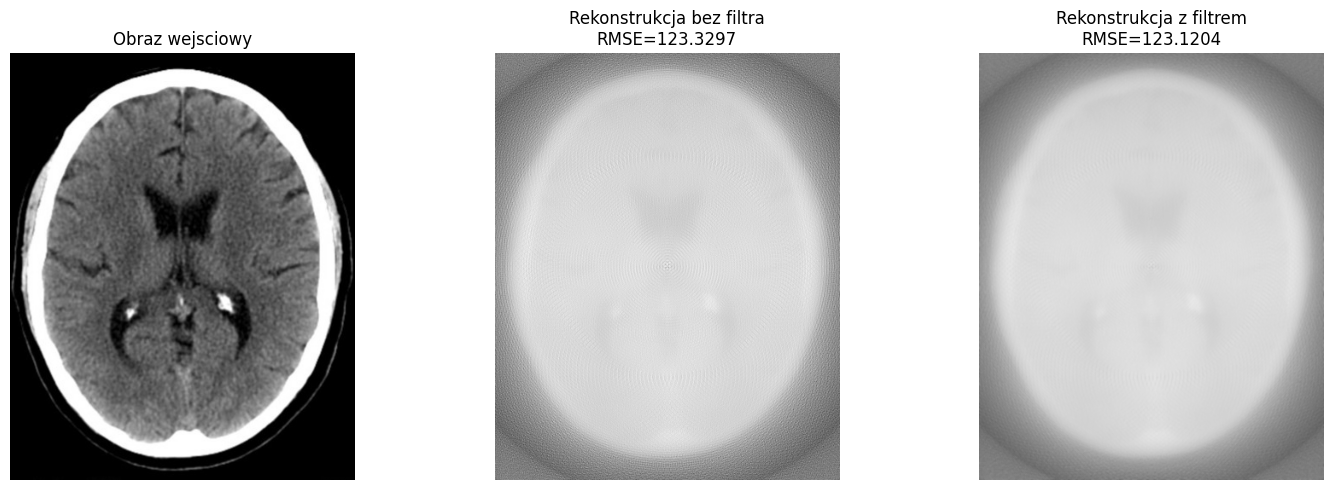

KeyboardInterrupt: 

In [44]:
from scipy.signal import convolve2d

# ---- Konfiguracja sekcji 4 ----
analysis_image_path = "image.bmp"

base_num_detectors = 181
base_spread_angle = 180
base_num_steps = 180
base_rotation_angle = 360

# Opcja aplikacji: wlacz/wylacz filtrowanie obrazu po rekonstrukcji
use_filter_in_app = True

# Co ile skanow liczyc RMSE podczas iteracyjnej rekonstrukcji
iteration_step = 10


def build_reconstruction_filter_kernel() -> np.ndarray:
    """
    Tworzy prosty kernel 3x3 do wygladzania rekonstrukcji (splot 2D).
    """
    kernel = np.array(
        [
            [1.0, 1.0, 1.0],
            [1.0, 2.0, 1.0],
            [1.0, 1.0, 1.0],
        ],
        dtype=np.float64,
    )
    kernel /= np.sum(kernel)
    return kernel


def apply_optional_reconstruction_filter(
    reconstructed_image: np.ndarray,
    use_filter: bool = False,
    kernel: np.ndarray | None = None,
) -> np.ndarray:
    """
    Opcjonalny filtr splotowy nakladany na obraz po odwrotnej transformacie Radona.
    """
    if not use_filter:
        return reconstructed_image

    if kernel is None:
        kernel = build_reconstruction_filter_kernel()

    filtered = convolve2d(
        reconstructed_image.astype(np.float64),
        kernel,
        mode="same",
        boundary="symm",
    )
    return np.clip(np.rint(filtered), 0, 255).astype(np.uint8)


def run_reconstruction_pipeline(
    image_array: np.ndarray,
    num_detectors: int,
    spread_angle: float,
    num_steps: int,
    rotation_angle: float = 360.0,
    use_filter: bool = False,
    kernel: np.ndarray | None = None,
):
    """
    Pelny przebieg: obraz -> sinogram -> rekonstrukcja -> (opcjonalny filtr).
    """
    base_sinogram_data = radon(
        image=image_array,
        num_detectors=num_detectors,
        spread_angle=spread_angle,
        num_steps=num_steps,
        rotation_angle=rotation_angle,
    )

    raw_reconstruction = inverse_radon(base_sinogram_data, image_array.shape)
    final_reconstruction = apply_optional_reconstruction_filter(
        raw_reconstruction,
        use_filter=use_filter,
        kernel=kernel,
    )

    return base_sinogram_data, raw_reconstruction, final_reconstruction


def compute_rmse(reference_image: np.ndarray, compared_image: np.ndarray) -> float:
    """
    Liczy RMSE dla dwoch obrazow 2D.
    """
    return float(
        np.sqrt(
            mean_squared_error(
                reference_image.astype(np.float64),
                compared_image.astype(np.float64),
            )
        )
    )


def build_partial_sinogram_data(sinogram_data: SinogramData, scans_count: int) -> SinogramData:
    """
    Buduje skrocony sinogram oraz odpowiadajace mu pozycje dla pierwszych `scans_count` iteracji.
    """
    if scans_count < 1 or scans_count > sinogram_data.scan_positions.num_scans:
        raise ValueError("scans_count poza zakresem.")

    partial_scan_positions = ScanPositions(
        detector_spread_angle=sinogram_data.scan_positions.detector_spread_angle,
        num_scans=scans_count,
        num_detectors=sinogram_data.scan_positions.num_detectors,
        scans=sinogram_data.scan_positions.scans[:scans_count],
    )

    return SinogramData(
        sinogram=sinogram_data.sinogram[:scans_count, :],
        scan_positions=partial_scan_positions,
    )


def rmse_over_inverse_radon_iterations(
    reference_image: np.ndarray,
    full_sinogram_data: SinogramData,
    iteration_step: int = 10,
    use_filter: bool = False,
    kernel: np.ndarray | None = None,
):
    """
    Liczy RMSE wraz z kolejnymi iteracjami odwrotnej transformaty Radona.
    """
    if iteration_step < 1:
        raise ValueError("iteration_step musi byc >= 1.")

    max_scans = full_sinogram_data.scan_positions.num_scans
    scan_indices = list(range(iteration_step, max_scans + 1, iteration_step))
    if not scan_indices or scan_indices[-1] != max_scans:
        scan_indices.append(max_scans)

    rmse_values = []
    for scans_count in scan_indices:
        partial_data = build_partial_sinogram_data(full_sinogram_data, scans_count)
        reconstructed_partial = inverse_radon(partial_data, reference_image.shape)
        reconstructed_partial = apply_optional_reconstruction_filter(
            reconstructed_partial,
            use_filter=use_filter,
            kernel=kernel,
        )
        rmse_values.append(compute_rmse(reference_image, reconstructed_partial))

    return scan_indices, rmse_values


def analyze_sampling_rmse(
    reference_image: np.ndarray,
    base_num_detectors: int,
    base_spread_angle: float,
    base_num_steps: int,
    rotation_angle: float,
    detector_values: list[int],
    spread_values: list[float],
    steps_values: list[int],
    use_filter: bool = False,
    kernel: np.ndarray | None = None,
):
    """
    Liczy RMSE przy zmianie trzech parametrow modelu emiter/detektor:
    liczby detektorow, rozpietosci katowej detektorow i liczby skanow.
    """
    detectors_rmse = []
    for val in detector_values:
        _, _, rec = run_reconstruction_pipeline(
            reference_image,
            num_detectors=val,
            spread_angle=base_spread_angle,
            num_steps=base_num_steps,
            rotation_angle=rotation_angle,
            use_filter=use_filter,
            kernel=kernel,
        )
        detectors_rmse.append(compute_rmse(reference_image, rec))

    spread_rmse = []
    for val in spread_values:
        _, _, rec = run_reconstruction_pipeline(
            reference_image,
            num_detectors=base_num_detectors,
            spread_angle=val,
            num_steps=base_num_steps,
            rotation_angle=rotation_angle,
            use_filter=use_filter,
            kernel=kernel,
        )
        spread_rmse.append(compute_rmse(reference_image, rec))

    steps_rmse = []
    for val in steps_values:
        _, _, rec = run_reconstruction_pipeline(
            reference_image,
            num_detectors=base_num_detectors,
            spread_angle=base_spread_angle,
            num_steps=val,
            rotation_angle=rotation_angle,
            use_filter=use_filter,
            kernel=kernel,
        )
        steps_rmse.append(compute_rmse(reference_image, rec))

    return {
        "detectors_values": detector_values,
        "detectors_rmse": detectors_rmse,
        "spread_values": spread_values,
        "spread_rmse": spread_rmse,
        "steps_values": steps_values,
        "steps_rmse": steps_rmse,
    }


# ---- Uruchomienie analiz z rozdzialu 4 ----
analysis_image = load_image(analysis_image_path)
if analysis_image is None:
    raise FileNotFoundError(f"Nie znaleziono obrazu: {analysis_image_path}")

reconstruction_kernel = build_reconstruction_filter_kernel()

# Opcja filtrowania w aplikacji
base_sinogram_data, reconstruction_without_filter, _ = run_reconstruction_pipeline(
    analysis_image,
    num_detectors=base_num_detectors,
    spread_angle=base_spread_angle,
    num_steps=base_num_steps,
    rotation_angle=base_rotation_angle,
    use_filter=False,
    kernel=reconstruction_kernel,
)
_, _, reconstruction_with_filter = run_reconstruction_pipeline(
    analysis_image,
    num_detectors=base_num_detectors,
    spread_angle=base_spread_angle,
    num_steps=base_num_steps,
    rotation_angle=base_rotation_angle,
    use_filter=True,
    kernel=reconstruction_kernel,
)
_, _, reconstruction_app_mode = run_reconstruction_pipeline(
    analysis_image,
    num_detectors=base_num_detectors,
    spread_angle=base_spread_angle,
    num_steps=base_num_steps,
    rotation_angle=base_rotation_angle,
    use_filter=use_filter_in_app,
    kernel=reconstruction_kernel,
)

rmse_without_filter = compute_rmse(analysis_image, reconstruction_without_filter)
rmse_with_filter = compute_rmse(analysis_image, reconstruction_with_filter)
rmse_app_mode = compute_rmse(analysis_image, reconstruction_app_mode)

print(f"Tryb aplikacji -> use_filter_in_app={use_filter_in_app}, RMSE={rmse_app_mode:.4f}")
print(f"RMSE bez filtra: {rmse_without_filter:.4f}")
print(f"RMSE z filtrem : {rmse_with_filter:.4f}")
print(f"Zmiana RMSE po filtrowaniu (bez - z): {rmse_without_filter - rmse_with_filter:+.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(analysis_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Obraz wejsciowy")
axes[0].axis("off")

axes[1].imshow(reconstruction_without_filter, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Rekonstrukcja bez filtra\nRMSE={rmse_without_filter:.4f}")
axes[1].axis("off")

axes[2].imshow(reconstruction_with_filter, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Rekonstrukcja z filtrem\nRMSE={rmse_with_filter:.4f}")
axes[2].axis("off")
plt.tight_layout()
plt.show()

# 1) Zmiana RMSE podczas kolejnych iteracji odwrotnej transformaty Radona
iteration_indices, rmse_iter_without_filter = rmse_over_inverse_radon_iterations(
    analysis_image,
    base_sinogram_data,
    iteration_step=iteration_step,
    use_filter=False,
    kernel=reconstruction_kernel,
)
_, rmse_iter_with_filter = rmse_over_inverse_radon_iterations(
    analysis_image,
    base_sinogram_data,
    iteration_step=iteration_step,
    use_filter=True,
    kernel=reconstruction_kernel,
)

plt.figure(figsize=(8, 5))
plt.plot(iteration_indices, rmse_iter_without_filter, marker="o", label="Bez filtrowania")
plt.plot(iteration_indices, rmse_iter_with_filter, marker="s", label="Z filtrowaniem")
plt.xlabel("Liczba uzytych iteracji (skanow)")
plt.ylabel("RMSE")
plt.title("RMSE w kolejnych iteracjach odwrotnej transformaty Radona")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Zmiana RMSE przy zwiekszaniu dokladnosci probkowania (3 parametry modelu)
detector_values = [45, 90, 135, 181, 225]
spread_values = [60, 90, 120, 150, 180]
steps_values = [45, 90, 135, 180, 225]

sampling_results = analyze_sampling_rmse(
    analysis_image,
    base_num_detectors=base_num_detectors,
    base_spread_angle=base_spread_angle,
    base_num_steps=base_num_steps,
    rotation_angle=base_rotation_angle,
    detector_values=detector_values,
    spread_values=spread_values,
    steps_values=steps_values,
    use_filter=use_filter_in_app,
    kernel=reconstruction_kernel,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    sampling_results["detectors_values"],
    sampling_results["detectors_rmse"],
    marker="o",
)
axes[0].set_title("RMSE vs liczba detektorow")
axes[0].set_xlabel("Liczba detektorow")
axes[0].set_ylabel("RMSE")
axes[0].grid(alpha=0.3)

axes[1].plot(
    sampling_results["spread_values"],
    sampling_results["spread_rmse"],
    marker="o",
    color="tab:orange",
)
axes[1].set_title("RMSE vs rozpietosc katowa detektorow")
axes[1].set_xlabel("Rozpietosc [stopnie]")
axes[1].set_ylabel("RMSE")
axes[1].grid(alpha=0.3)

axes[2].plot(
    sampling_results["steps_values"],
    sampling_results["steps_rmse"],
    marker="o",
    color="tab:green",
)
axes[2].set_title("RMSE vs liczba skanow")
axes[2].set_xlabel("Liczba skanow")
axes[2].set_ylabel("RMSE")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3) Zmiana RMSE po wlaczeniu filtrowania
labels = ["Bez filtrowania", "Z filtrowaniem"]
values = [rmse_without_filter, rmse_with_filter]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=["tab:red", "tab:blue"])
plt.ylabel("RMSE")
plt.title("Wplyw filtrowania rekonstrukcji na RMSE")
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val:.4f}",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

## Y. Funkcje pomocnicze

In [ ]:
class StopExecution(Exception):
    """
    Usage example:
        if 1:
            raise StopExecution
    """
    def _render_traceback_(self):
        # Zwrócenie pustej listy powoduje, że nie będzie wyświetlany traceback
        return []

## Z. Raport

### Informacje o projekcie

Skład grupy:

- Paweł Spychała 160157
- Krzysztof Gągało 160152

Zastosowany model tomografu:

- stożkowy

Zastosowany język programowania oraz dodatkowe biblioteki:

- Python
- Użyte biblioteki poza wbudowanymi: `Pillow` `matplotlib` `numpy` `scipy` `scikit-image` `pydicom` `ipywidgets`



### Interaktywna prezentacja działania programu (pierwszy obrazek)

**Ustawienia wstępne (dialog z użytkownikiem)**

In [45]:
ans = input("Czy pokazywać czasochłonne wizualizacje? (Y/n): ").strip().lower()

visualize = True
if ans and ans[0] == 'n':
    visualize = False

print(visualize)

False


In [46]:
ans = input("Czy chcesz ręcznie wprowadzić dane? (y/N): ").strip().lower()

manual = False
if ans and (ans[0] == 'y' or ans in ['tak', 't']):
    manual = True

print(manual)

True


Definicja przykładowych (domyślnych) danych:

In [47]:
# Ścieżka do obrazu:
# path = "tomograf-obrazy/.jpg"
# path = "tomograf-obrazy/Kolo.jpg"
# path = "tomograf-obrazy/Paski2.jpg"
# path = "tomograf-obrazy/Kropka.jpg"
path = "tomograf-obrazy/Shepp_logan.jpg"

# (1.2.3. -> Zwykły, pełen sinogram)
num_detectors = 181
spread_angle = 180
num_steps = 180
rotation_angle = 360

# (1.2.3. -> Wizualizacja iteracji generowania sinogramu)
scan_vis_steps = 6
reconstruction_vis_steps = 4

# (3.1. -> Zapis DICOM)
path_reconstructed_image = "output/reconstructed_image.dcm" # Tego aktualnie nie pozwalamy zmieniać
dicom_patient_first_name = "Wlodzimierz"
dicom_patient_last_name = "Bialy"
dicom_patient_name = f"{dicom_patient_last_name}^{dicom_patient_first_name}"
dicom_patient_id = "672000"
dicom_comment = "Pacjent nie jest w niebezpieczenstwie."

# (3.2. -> Odczyt DICOM)
path_dicom_to_read = "tomograf-dicom/SADDLE_PE.dcm"

Pobranie parametrów skanowania:

In [48]:
if manual:
    while True:
        ans = input("Podaj parametry skanowania (lub pozostaw puste, by użyć domyślnych). Format: \"liczba_detektorów kąt_detektorów liczba_kroków_skanowania kąt_obrotu\". (Domyślnie: \"181 180 180 360\"): ").strip()
        if not ans:
            break
        try:
            num_detectors, spread_angle, num_steps, rotation_angle = map(float, ans.split())
            num_detectors = int(num_detectors)
            num_steps = int(num_steps)
            break
        except Exception as e:
            print(f"Wprowadzono nieprawidłowy format danych: {e}")
    
    if visualize:
        while True:
            ans = input(f"Ile kroków powstawania sinogramu pokazać? (lub pozostaw puste, by użyć domyślnej: {scan_vis_steps})").strip()
            if not ans:
                if scan_vis_steps <= num_steps:
                    break
                else:
                    print(f"Należy wprowadzić liczbę kroków wizualizacji, która nie może być większa niż liczba kroków skanowania ({num_steps}).")
                    continue
            try:
                if int(ans) <= num_steps:
                    scan_vis_steps = int(ans)
                    break
                else:
                    print(f"Wprowadzona liczba kroków wizualizacji nie może być większa niż liczba kroków skanowania ({num_steps}).")
                    continue
            except Exception as e:
                print(f"Wprowadzono nieprawidłowy format danych: {e}")
        while True:
            ans = input(f"Ile kroków rekonstrukcji obrazu pokazać? (lub pozostaw puste, by użyć domyślnej: {reconstruction_vis_steps})").strip()
            if not ans:
                if reconstruction_vis_steps <= num_steps:
                    break
                else:
                    print(f"Należy wprowadzić liczbę kroków wizualizacji, która nie może być większa niż liczba kroków skanowania ({num_steps}).")
                    continue
            try:
                if int(ans) <= num_steps:
                    reconstruction_vis_steps = int(ans)
                    break
                else:
                    print(f"Wprowadzona liczba kroków wizualizacji nie może być większa niż liczba kroków skanowania ({num_steps}).")
            except Exception as e:
                print(f"Wprowadzono nieprawidłowy format danych: {e}")
    while True:
        ans = input(f"Podaj ścieżkę do pliku DICOM do odczytu (lub pozostaw puste, by użyć domyślnej: \"{path_dicom_to_read}\"): ").strip().strip('"').strip("'")

        if not ans:
            break
            
        try:
            with open(ans, 'rb'):
                path_dicom_to_read = ans
                break 
        except Exception as e:
            print(f"Nie można otworzyć pliku {ans}: {e}")
    
    ans = input(f"Podaj imię do zapisu DICOM bez polskich znaków (lub pozostaw puste, by użyć domyślnego: \"{dicom_patient_first_name}\"): ").strip()
    if ans:
        dicom_patient_first_name = ans
    
    ans = input(f"Podaj nazwisko do zapisu DICOM bez polskich znaków (lub pozostaw puste, by użyć domyślnego: \"{dicom_patient_last_name}\"): ").strip()
    if ans:
        dicom_patient_last_name = ans

    dicom_patient_name = f"{dicom_patient_last_name}^{dicom_patient_first_name}"

    ans = input(f"Podaj ID pacjenta do zapisu DICOM (lub pozostaw puste, by użyć domyślnego: \"{dicom_patient_id}\"): ").strip()
    if ans:
        dicom_patient_id = ans
    
    ans = input(f"Podaj komentarz do zapisu DICOM bez polskich znaków (lub pozostaw puste, by użyć domyślnego: \"{dicom_comment}\"): ").strip()
    if ans:
        dicom_comment = ans

print(num_detectors, spread_angle, num_steps, rotation_angle)
print(scan_vis_steps)
print(reconstruction_vis_steps)
print(path_dicom_to_read)
print(dicom_patient_name)
print(dicom_patient_id)
print(dicom_comment)

181 180 180 360
6
4
image.bmp
Bialy^Wlodzimierz
672000
Pacjent nie jest w niebezpieczenstwie.


#### 1.1. -> Wczytanie pliku

In [49]:
# Wczytanie obrazu
image = load_image(path)

#### 1.2.3. -> Zwykły, pełen sinogram

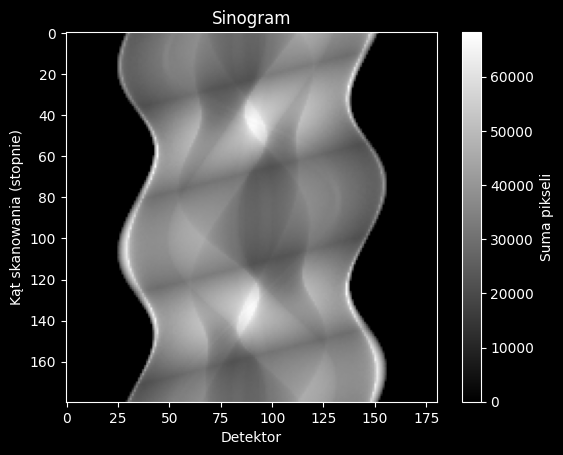

In [50]:
sinogram_data = radon(
    image=image,
    num_detectors=num_detectors,
    spread_angle=spread_angle,
    num_steps=num_steps,
    rotation_angle=rotation_angle,
) 
plot_sinogram(sinogram_data.sinogram)

#### 1.2.3. -> Wizualizacja iteracji generowania sinogramu

In [51]:
if visualize:
    simulate_scan(
        image,
        sinogram_data,
        draw_every=sinogram_data.scan_positions.num_scans // scan_vis_steps,
    )

#### 2.1. -> Zrekonstruowany obraz z sinogramu

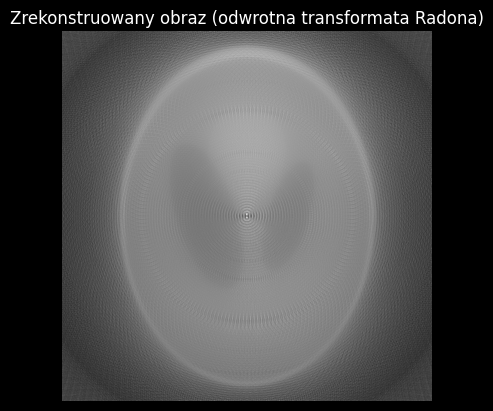

In [52]:
# Obliczenie pełnego zrekonstruowanego obrazu
reconstructed_image = inverse_radon(sinogram_data, image.shape)
plot_reconstruction(reconstructed_image)

#### 2.2. -> Wizualizacja iteracji rekonstrukcji obrazu z sinogramu

In [53]:
if visualize:
    simulate_reconstruction(
        sinogram_data,
        image.shape,
        step=sinogram_data.scan_positions.num_scans // reconstruction_vis_steps,
        delay=0.0,
    )

#### 3.1. -> Zapis DICOM

In [54]:
save_np_uint8_image_to_dicom(
    reconstructed_image,
    path_reconstructed_image,
    patient_name=dicom_patient_name,
    patient_id=dicom_patient_id,
    komentarz=dicom_comment,
)

#### 3.2. -> Odczyt DICOM

In [56]:
image_from_created_dicom = read_uint8_image_from_dicom(path_reconstructed_image)
image_from_given_dicom = read_uint8_image_from_dicom(path_dicom_to_read)

print("Obrazy odczytane z DICOM-ów:")
with plt.style.context("dark_background"):
    plt.subplot(1, 2, 1)
    plt.imshow(image_from_given_dicom, cmap="gray")
    plt.subplot(1, 2, 2)
    plt.imshow(image_from_created_dicom, cmap="gray")
    plt.show()

---------------------------------------------------------------------

Ścieżka wczytanego pliku DICOM    : output/reconstructed_image.dcm

Imię i nazwisko pacjenta  : Bialy, Wlodzimierz
ID pacjenta               : 672000
Modality                  : CT
Wymiary obrazu            : 1024 x 1024
Komentarz                 : Pacjent nie jest w niebezpieczenstwie.
Data i czas utworzenia    : 2026-04-20 11:49:43.913465

---------------------------------------------------------------------


InvalidDicomError: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.

### Prezentacja działania programu (drugi obrazek)

In [ ]:
visualize_2 = False

# Ścieżka do obrazu:
path2 = "tomograf-obrazy/CT_ScoutView.jpg"

# (1.2.3. -> Zwykły, pełen sinogram)
num_detectors_2 = 181
spread_angle_2 = 180
num_steps_2 = 180
rotation_angle_2 = 360

# (1.2.3. -> Wizualizacja iteracji generowania sinogramu)
scan_vis_steps_2 = 6
reconstruction_vis_steps_2 = 4

# (3.1. -> Zapis DICOM)
path_reconstructed_image_2 = "output/reconstructed_image.dcm" # Tego aktualnie nie pozwalamy zmieniać
dicom_patient_first_name_2 = "Jeremiasz"
dicom_patient_last_name_2 = "Rozowy"
dicom_patient_name_2 = f"{dicom_patient_last_name_2}^{dicom_patient_first_name_2}"
dicom_patient_id_2 = "1483369"
dicom_comment_2 = "W pacjencie znaleziono drut i magnesy."

# (3.2. -> Odczyt DICOM)
path_dicom_to_read_2 = "tomograf-dicom/CT_ScoutView.dcm"

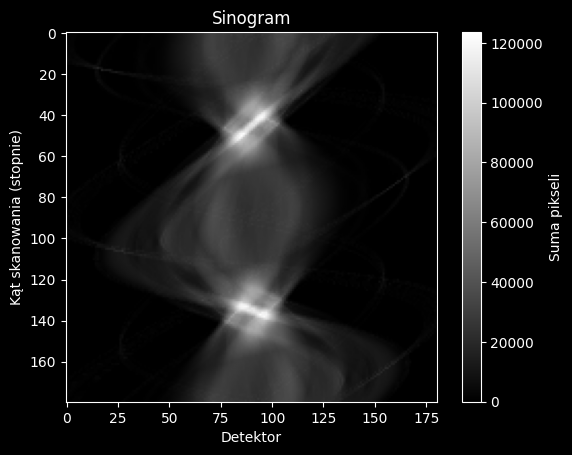

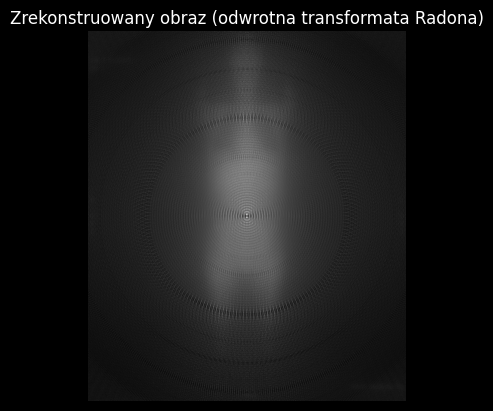

---------------------------------------------------------------------

Ścieżka wczytanego pliku DICOM    : output/reconstructed_image.dcm

Imię i nazwisko pacjenta  : Rozowy, Jeremiasz
ID pacjenta               : 1483369
Modality                  : CT
Wymiary obrazu            : 1024 x 880
Komentarz                 : W pacjencie znaleziono drut i magnesy.
Data i czas utworzenia    : 2026-04-20 11:20:08.021270

---------------------------------------------------------------------
---------------------------------------------------------------------

Ścieżka wczytanego pliku DICOM    : tomograf-dicom/CT_ScoutView.dcm

Imię i nazwisko pacjenta  : Doe, John
ID pacjenta               : 42
Modality                  : CT
Wymiary obrazu            : 1024 x 880
Komentarz                 : what a lovely image we have here...

---------------------------------------------------------------------

Obrazy odczytane z DICOM-ów:


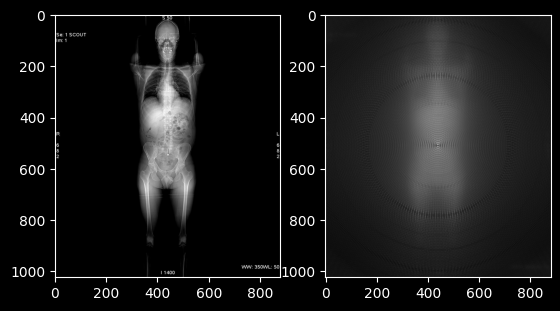

In [ ]:
# Wczytanie obrazu
image_2 = load_image(path2)

# Zwykły, pełen sinogram
sinogram_data_2 = radon(
    image=image_2,
    num_detectors=num_detectors_2,
    spread_angle=spread_angle_2,
    num_steps=num_steps_2,
    rotation_angle=rotation_angle_2,
) 
plot_sinogram(sinogram_data_2.sinogram)

# Wizualizacja iteracji generowania sinogramu
if visualize_2:
    simulate_scan(
        image_2,
        sinogram_data_2,
        draw_every=sinogram_data_2.scan_positions.num_scans // scan_vis_steps_2,
    )

# Zrekonstruowany obraz z sinogramu
reconstructed_image_2 = inverse_radon(sinogram_data_2, image_2.shape)
plot_reconstruction(reconstructed_image_2)

# Wizualizacja iteracji rekonstrukcji obrazu z sinogramu
if visualize_2:
    simulate_reconstruction(
        sinogram_data_2,
        image_2.shape,
        step=sinogram_data_2.scan_positions.num_scans // reconstruction_vis_steps_2,
        delay=0.0,
    )

# Zapis DICOM
save_np_uint8_image_to_dicom(
    reconstructed_image_2,
    path_reconstructed_image_2,
    patient_name=dicom_patient_name_2,
    patient_id=dicom_patient_id_2,
    komentarz=dicom_comment_2,
)

# Odczyt DICOM
image_from_created_dicom_2 = read_uint8_image_from_dicom(path_reconstructed_image_2)
image_from_given_dicom_2 = read_uint8_image_from_dicom(path_dicom_to_read_2)

print()
print("Obrazy odczytane z DICOM-ów:")
with plt.style.context("dark_background"):
    plt.subplot(1, 2, 1)
    plt.imshow(image_from_given_dicom_2, cmap="gray")
    plt.subplot(1, 2, 2)
    plt.imshow(image_from_created_dicom_2, cmap="gray")
    plt.show()